Cell-1 (Custom booster.py)

In [37]:
import gymnasium as gym
import numpy as np
from gymnasium import spaces
import pygame
from pygame import gfxdraw

class CustomBoosterEnv(gym.Env):
    metadata = {"render_modes": ["human", "rgb_array"], "render_fps": 50}

    def __init__(self, render_mode=None):
        super(CustomBoosterEnv, self).__init__()
        self.render_mode = render_mode
        self.action_space = spaces.Box(low=-1, high=1, shape=(5,), dtype=np.float32)
        self.target_center = np.array([0., 0., 0.])
        self.target_size = 100.0
        self.observation_space = spaces.Box(-np.inf, np.inf, shape=(10,), dtype=np.float32)

        self.params = {
            'm_dry': 50.0,
            'g': 9.81,
            'I_t': 10.0,
            'l1': 1.0,
            'l2': 0.5,
            'T_p_max': 1200.0,   # slightly higher thrust authority
            'T_g_max': 120.0,
            'mu_max': 0.12,
            'dt': 0.02,
            'rocket_length': 3.0,
        }
        self.state = None
        self.steps = 0
        self.max_steps = 6000   # give more time

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        if seed is not None:
            np.random.seed(seed)
        self.state = np.array([
            np.random.uniform(80, 100),     # higher start
            np.random.uniform(-180, -80),
            np.random.uniform(-80, 180),
            np.random.uniform(-18, -8),     # stronger downward speed
            np.random.uniform(-8, 8),
            np.random.uniform(-8, 8),
            np.random.uniform(-0.3, 0.3),
            np.random.uniform(-0.3, 0.3),
            0.0, 0.0
        ], dtype=np.float32)
        self.steps = 0
        return self.state.copy(), {}

    def step(self, action):
        action = np.clip(action, -1, 1)
        Tp_s, Tgy_s, Tgz_s, mup_s, muy_s = action

        m = self.params['m_dry']
        T_hover = m * self.params['g']
        T_p = T_hover + Tp_s * (self.params['T_p_max'] - T_hover)
        T_p = max(0, T_p)
        T_gy = Tgy_s * self.params['T_g_max']
        T_gz = Tgz_s * self.params['T_g_max']
        mu_p = mup_s * self.params['mu_max']
        mu_y = muy_s * self.params['mu_max']

        x,y,z, u,v,w, theta,psi, q,r = self.state
        dt = self.params['dt']

        ct,st = np.cos(theta), np.sin(theta)
        cp,sp = np.cos(psi), np.sin(psi)
        cmp,smp = np.cos(mu_p), np.sin(mu_p)
        cmy,smy = np.cos(mu_y), np.sin(mu_y)

        # Gravity in body frame (corrected)
        Fg_x = -self.params['g'] * ct * cp * m
        Fg_y = -self.params['g'] * ct * sp * m
        Fg_z = self.params['g'] * st * m

        Fp_x = T_p * cmp * cmy
        Fp_y = -T_p * cmp * smy
        Fp_z = -T_p * smp

        Fr_x, Fr_y, Fr_z = 0, T_gy, T_gz

        Fx = Fg_x + Fp_x + Fr_x
        Fy = Fg_y + Fp_y + Fr_y
        Fz = Fg_z + Fp_z + Fr_z

        dot_u = Fx/m + r*v - q*w
        dot_v = Fy/m - r*u
        dot_w = Fz/m + q*u

        My = -T_p*self.params['l1']*smp + (-T_gz*self.params['l2'])
        Mz = T_p*self.params['l1']*cmp*smy + T_gy*self.params['l2']

        dot_q = My / self.params['I_t']
        dot_r = Mz / self.params['I_t']

        dot_theta = q
        dot_psi = r / ct if abs(theta) < np.pi/2 else 0

        dot_x = ct*cp*u - sp*v + ct*sp*w
        dot_y = sp*cp*u + cp*v + sp*st*w
        dot_z = -st*u + ct*w

        self.state += dt * np.array([dot_x, dot_y, dot_z, dot_u, dot_v, dot_w,
                                     dot_theta, dot_psi, dot_q, dot_r])

        self.steps += 1

        pos = self.state[:3]
        vel = self.state[3:6]
        att = np.abs(self.state[6:8])
        rates = self.state[8:10]

        terminated = False
        truncated = self.steps >= self.max_steps

        if self.state[0] <= 0.1:
            in_square = np.all(np.abs(pos[1:3]) < self.target_size/2)
            good_land = in_square and np.linalg.norm(vel) < 2.5 and np.max(att) < 0.15 and np.linalg.norm(rates) < 0.8
            terminated = True
            if good_land:
                reward = 250.0
            else:
                reward = -150.0
        elif self.state[0] < -2.0:
            terminated = True
            reward = -200.0
        elif np.max(att) > np.pi/2 + 0.2:
            terminated = True
            reward = -120.0
        else:
            reward = 0.0

        # Stronger incentives
        reward -= 0.015 * self.state[0]             # descend faster
        reward -= 0.15                              # time penalty (strong)
        reward -= 0.0008 * T_p * dt
        reward -= 0.0015 * (abs(T_gy) + abs(T_gz)) * dt
        reward -= 0.0008 * np.linalg.norm(pos[1:3])
        reward -= 0.015 * np.linalg.norm(vel)
        reward -= 0.2 * np.sum(att)
        reward -= 0.08 * np.sum(np.abs(rates))

        return self.state.copy(), reward, terminated, truncated, {}

    def render(self):
        if self.render_mode == "rgb_array":
            return self._render_frame()
        # ... (keep your current render code)
        # (omitted for brevity - keep as is)

    def _render_frame(self):
        if self.viewer is None:
            self.render_mode = "rgb_array"
            self.render()
        return np.transpose(np.array(pygame.surfarray.pixels3d(self.viewer)), axes=(1, 0, 2))

    def close(self):
        if self.viewer is not None:
            pygame.display.quit()
            pygame.quit()
            self.viewer = None

Cell 2: Code (train.py)

In [38]:
from stable_baselines3.common.vec_env import SubprocVecEnv, VecNormalize
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3 import PPO
from multiprocessing import freeze_support
import tqdm  # for simple progress

if __name__ == "__main__":
    freeze_support()
    env = make_vec_env(CustomBoosterEnv, n_envs=32, vec_env_cls=SubprocVecEnv)
    env = VecNormalize(env, norm_obs=True, norm_reward=False)
    model = PPO("MlpPolicy", env, verbose=1, device="cpu",
                batch_size=512, n_steps=2048, n_epochs=10,
                learning_rate=3e-4, clip_range=0.2)
    model.learn(total_timesteps=12000000, progress_bar=True)
    model.save("ppo_booster")

Output()

Using cpu device


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 97.6     |
|    ep_rew_mean     | -312     |
| time/              |          |
|    fps             | 11667    |
|    iterations      | 1        |
|    time_elapsed    | 5        |
|    total_timesteps | 65536    |
---------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 182         |
|    ep_rew_mean          | -490        |
| time/                   |             |
|    fps                  | 8455        |
|    iterations           | 3           |
|    time_elapsed         | 23          |
|    total_timesteps      | 196608      |
| train/                  |             |
|    approx_kl            | 0.005389559 |
|    clip_fraction        | 0.0467      |
|    clip_range           | 0.2         |
|    entropy_loss         | -7.12       |
|    explained_variance   | 0.011549771 |
|    learning_rate        | 0.0003      |
|    loss                 | 123         |
|    n_updates            | 20          |
|    policy_gradient_loss | -0.00437    |
|    std                  | 1.01        |
|    value_loss           | 706         |
-----------------------------------------


------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 259          |
|    ep_rew_mean          | -667         |
| time/                   |              |
|    fps                  | 8145         |
|    iterations           | 4            |
|    time_elapsed         | 32           |
|    total_timesteps      | 262144       |
| train/                  |              |
|    approx_kl            | 0.005510997  |
|    clip_fraction        | 0.0458       |
|    clip_range           | 0.2          |
|    entropy_loss         | -7.13        |
|    explained_variance   | 0.0016944408 |
|    learning_rate        | 0.0003       |
|    loss                 | 51.5         |
|    n_updates            | 30           |
|    policy_gradient_loss | -0.00404     |
|    std                  | 1.01         |
|    value_loss           | 340          |
------------------------------------------


...

------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 4.47e+03     |
|    ep_rew_mean          | -1.67e+03    |
| time/                   |              |
|    fps                  | 6110         |
|    iterations           | 180          |
|    time_elapsed         | 1930         |
|    total_timesteps      | 11796480     |
| train/                  |              |
|    approx_kl            | 0.0129586095 |
|    clip_fraction        | 0.166        |
|    clip_range           | 0.2          |
|    entropy_loss         | -3           |
|    explained_variance   | 0.968493     |
|    learning_rate        | 0.0003       |
|    loss                 | 0.756        |
|    n_updates            | 1790         |
|    policy_gradient_loss | -0.000858    |
|    std                  | 0.449        |
|    value_loss           | 7.63         |
------------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.78e+03    |
|    ep_rew_mean          | -1.75e+03   |
| time/                   |             |
|    fps                  | 6105        |
|    iterations           | 181         |
|    time_elapsed         | 1942        |
|    total_timesteps      | 11862016    |
| train/                  |             |
|    approx_kl            | 0.018588604 |
|    clip_fraction        | 0.245       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.95       |
|    explained_variance   | 0.9661858   |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00773     |
|    n_updates            | 1800        |
|    policy_gradient_loss | -0.00143    |
|    std                  | 0.445       |
|    value_loss           | 5.62        |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.98e+03    |
|    ep_rew_mean          | -1.8e+03    |
| time/                   |             |
|    fps                  | 6098        |
|    iterations           | 182         |
|    time_elapsed         | 1955        |
|    total_timesteps      | 11927552    |
| train/                  |             |
|    approx_kl            | 0.014428339 |
|    clip_fraction        | 0.171       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.9        |
|    explained_variance   | 0.98894167  |
|    learning_rate        | 0.0003      |
|    loss                 | 0.00587     |
|    n_updates            | 1810        |
|    policy_gradient_loss | 0.000538    |
|    std                  | 0.439       |
|    value_loss           | 0.857       |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.87e+03    |
|    ep_rew_mean          | -1.77e+03   |
| time/                   |             |
|    fps                  | 6095        |
|    iterations           | 183         |
|    time_elapsed         | 1967        |
|    total_timesteps      | 11993088    |
| train/                  |             |
|    approx_kl            | 0.009431972 |
|    clip_fraction        | 0.127       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.79       |
|    explained_variance   | 0.99926585  |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0155      |
|    n_updates            | 1820        |
|    policy_gradient_loss | -0.000264   |
|    std                  | 0.43        |
|    value_loss           | 0.019       |
-----------------------------------------


-----------------------------------------
| rollout/                |             |
|    ep_len_mean          | 4.9e+03     |
|    ep_rew_mean          | -1.77e+03   |
| time/                   |             |
|    fps                  | 6094        |
|    iterations           | 184         |
|    time_elapsed         | 1978        |
|    total_timesteps      | 12058624    |
| train/                  |             |
|    approx_kl            | 0.015595499 |
|    clip_fraction        | 0.192       |
|    clip_range           | 0.2         |
|    entropy_loss         | -2.72       |
|    explained_variance   | 0.967774    |
|    learning_rate        | 0.0003      |
|    loss                 | 0.0189      |
|    n_updates            | 1830        |
|    policy_gradient_loss | 0.000715    |
|    std                  | 0.424       |
|    value_loss           | 4.28        |
-----------------------------------------


Cell -3(WATCH)

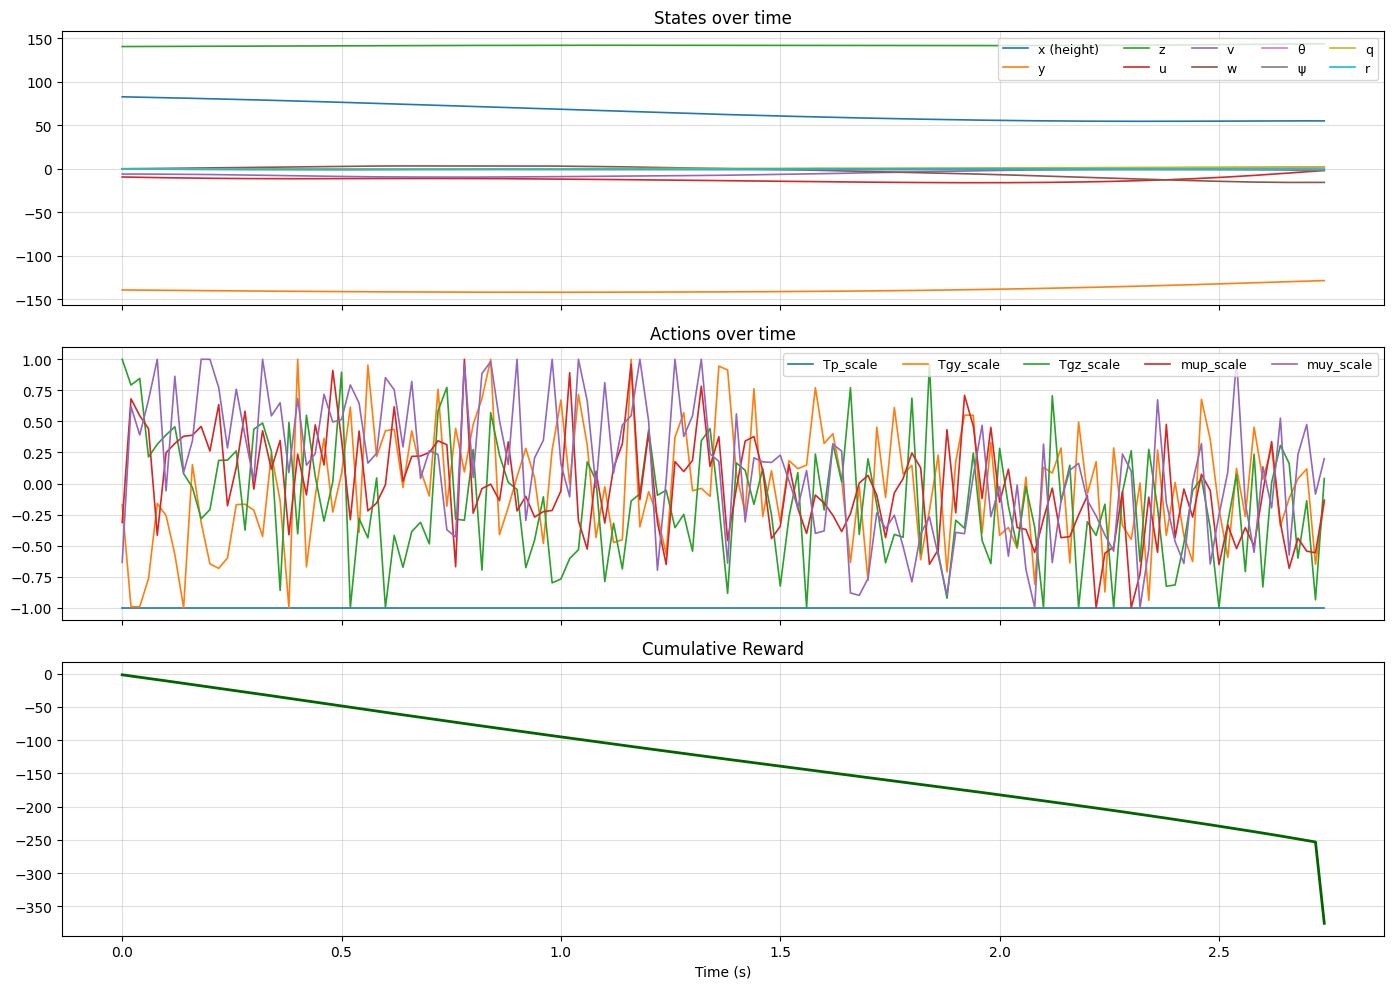

Video saved → landing_full.mp4


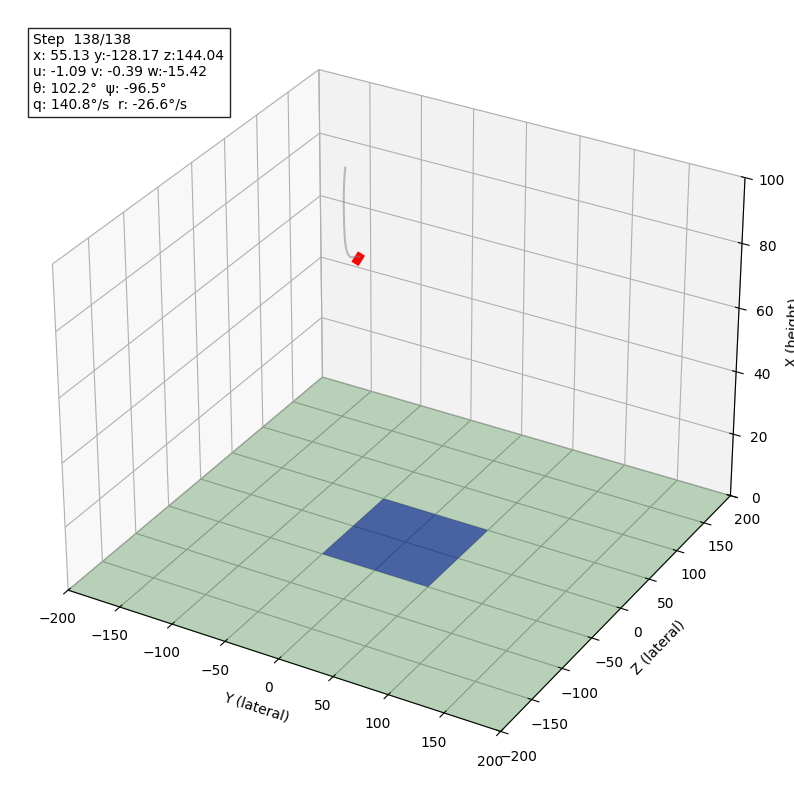

In [40]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from stable_baselines3 import PPO
import matplotlib.animation as animation
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.text import Annotation

# ── Create env & load model ────────────────────────────────────────────────
env = CustomBoosterEnv(render_mode="rgb_array")
model = PPO.load("ppo_booster")

# ── Rollout full episode ───────────────────────────────────────────────────
obs, _ = env.reset()
states = [obs.copy()]
actions = []
rewards = []
done = False
while not done:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)
    states.append(obs.copy())
    actions.append(action.copy())
    rewards.append(reward)
    done = terminated or truncated

# No need for env.close() when render_mode="rgb_array" (avoids crash)
# env.close()   ← comment or remove this line

states = np.array(states)
actions = np.array(actions)
times = np.arange(len(actions)) * env.params['dt']

# ── State & action plots ───────────────────────────────────────────────────
fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

# States
state_names = ['x (height)', 'y', 'z', 'u', 'v', 'w', 'θ', 'ψ', 'q', 'r']
for i, name in enumerate(state_names):
    axs[0].plot(times, states[:-1, i], label=name, lw=1.2)
axs[0].legend(ncol=5, fontsize=9)
axs[0].set_title("States over time")
axs[0].grid(True, alpha=0.4)

# Actions
action_names = ['Tp_scale', 'Tgy_scale', 'Tgz_scale', 'mup_scale', 'muy_scale']
for i, name in enumerate(action_names):
    axs[1].plot(times, actions[:, i], label=name, lw=1.2)
axs[1].legend(ncol=5, fontsize=9)
axs[1].set_title("Actions over time")
axs[1].grid(True, alpha=0.4)

# Cumulative reward
axs[2].plot(times, np.cumsum(rewards), color='darkgreen', lw=2)
axs[2].set_title("Cumulative Reward")
axs[2].set_xlabel("Time (s)")
axs[2].grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

# ── 3D Animation ───────────────────────────────────────────────────────────
fig3d = plt.figure(figsize=(12, 10))
ax = fig3d.add_subplot(111, projection='3d')
ax.set_xlabel('Y (lateral)')
ax.set_ylabel('Z (lateral)')
ax.set_zlabel('X (height)')
ax.set_xlim(-200, 200)
ax.set_ylim(-200, 200)
ax.set_zlim(0, max(100, states[:,0].max()+10))

# Ground & pad
Yg, Zg = np.meshgrid(np.linspace(-200,200,2), np.linspace(-200,200,2))
ax.plot_surface(Yg, Zg, np.zeros_like(Yg), alpha=0.25, color='green')

Yp, Zp = np.meshgrid(np.linspace(-50,50,2), np.linspace(-50,50,2))
ax.plot_surface(Yp, Zp, np.zeros_like(Yp), alpha=0.6, color='blue')

cylinder, = ax.plot([], [], [], 'r-', lw=6)
flame, = ax.plot([], [], [], 'orange', lw=4)
trail, = ax.plot([], [], [], 'gray', alpha=0.5, lw=1.5)

metrics = ax.text2D(0.03, 0.97, "", transform=ax.transAxes,
                    va='top', bbox=dict(facecolor='white', alpha=0.85))

def update(i):
    p = states[i]
    ux = np.sin(p[6]) * np.cos(p[7])
    uy = np.sin(p[6]) * np.sin(p[7])
    uz = np.cos(p[6])
    dir_vec = np.array([ux, uy, uz])
    nose = np.array([p[1], p[2], p[0]]) + 3 * dir_vec
    tail = np.array([p[1], p[2], p[0]])

    cylinder.set_data_3d([tail[0], nose[0]], [tail[1], nose[1]], [tail[2], nose[2]])

    fl_len = 6 * abs(actions[i][0]) if i < len(actions) else 0
    f_end = tail - fl_len * dir_vec
    flame.set_data_3d([tail[0], f_end[0]], [tail[1], f_end[1]], [tail[2], f_end[2]])

    trail.set_data_3d(states[:i+1,1], states[:i+1,2], states[:i+1,0])

    txt = (f"Step {i:4d}/{len(states)-1}\n"
           f"x:{p[0]:6.2f} y:{p[1]:6.2f} z:{p[2]:6.2f}\n"
           f"u:{p[3]:6.2f} v:{p[4]:6.2f} w:{p[5]:6.2f}\n"
           f"θ:{np.degrees(p[6]):6.1f}°  ψ:{np.degrees(p[7]):6.1f}°\n"
           f"q:{np.degrees(p[8]):6.1f}°/s  r:{np.degrees(p[9]):6.1f}°/s")
    metrics.set_text(txt)

    return cylinder, flame, trail, metrics

ani = animation.FuncAnimation(fig3d, update, frames=len(states),
                              interval=20, blit=False, repeat=False)

ani.save('landing_full.mp4', writer='ffmpeg', fps=50, dpi=100)
print("Video saved → landing_full.mp4")
plt.show()